# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import glob
import os

## CARREGAMENTO, LIMPEZA E TRATAMENTO DOS ARQUIVOS INDIVIDUALMENTE

In [2]:
# Realizar esse processo para cada dataset da pasta uploads
arquivo_csv = ('uploads/analise_txcg_2025.csv')
df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8-sig')
print(df.shape)

C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_11836\1049088866.py:3: DtypeWarning: Columns (5,12,14,15,17,18,20,21,22,23,24,25,43,44,49,50,54,59,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8-sig')


(7874977, 64)


## VALIDAÇÃO RÁPIDA

In [3]:
pendentes = df['data_baixa'].isna().sum()
print(f"Pendentes: {pendentes}")

Pendentes: 1532336


In [4]:
baixados = df['data_baixa'].notna().sum()
print(f"Baixados: {baixados}")

Baixados: 6342641


In [5]:
tx_cong_global = (100 * pendentes/(pendentes+baixados)).round(2)
print(f"Taxa de Congestionamento Global: {tx_cong_global} %")

Taxa de Congestionamento Global: 19.46 %


In [ ]:
# Verificando se na coluna data_baixa e data_distribuicao tem o ANO e quantos são:
# Converte a coluna para o tipo datetime
ANO = 2026
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce') # errors='coerce' transforma erros em NaT (nulo)
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce') 

print("="*60)
print("--- VALIDAÇÃO DE DATA_BAIXA ---")
# Faz a verificação
temp = (df['data_baixa'].dt.year == ANO).any()
print(temp)

# Se quiser saber QUANTOS registros existem com o ano 2019:
qtd = (df['data_baixa'].dt.year == ANO).sum()
print(f"Total de registros de data_baixa em {ANO}: {qtd}")

print("="*60)
print("--- VALIDAÇÃO DE DATA_DISTRIBUICAO ---")
# Faz a verificação
temp2 = (df['data_distribuicao'].dt.year == ANO).any()
print(temp2)

# Se quiser saber QUANTOS registros existem com o ano 2019:
qtd2 = (df['data_distribuicao'].dt.year == ANO).sum()
print(f"Total de registros de data_distribuicao em {ANO}: {qtd2}")

## LIMPEZA E TRATAMENTO DAS DATAS DO ARQUIVO_CSV

In [14]:
# Limpeza e tratamento das datas do arquivo_csv
# 1. Converter as colunas de data para datetime
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

# 2. Verificar quantas datas inválidas temos
print(f"\nDatas inválidas na conversão:")
print(f"- data_distribuicao: {df['data_distribuicao'].isna().sum()} valores NaT")
print(f"- data_baixa: {df['data_baixa'].isna().sum()} valores NaT")

# 3. Extrair o ano de cada data
df['ano_distribuicao'] = df['data_distribuicao'].dt.year
df['ano_baixa'] = df['data_baixa'].dt.year

# 4. Fazer a limpeza: manter apenas registros em que:
#    - ano_distribuicao <= ANO (ou é NaN)
#    - ano_baixa <= ANO (ou é NaN)
ANO = 2025
df_limpo = df[
    (
        (df['ano_distribuicao'] <= ANO)
    ) & 
    (
        (df['ano_baixa'] >= 2020) & (df['ano_baixa'] <= ANO) | 
        (df['ano_baixa'].isna())
    )
].copy()

print(f"\nShape após limpeza: {df_limpo.shape}")
print(f"Registros removidos: {len(df) - len(df_limpo)}")

# 5. Verificação detalhada
print(f"\nVerificação dos anos nas datas:")
print(f"Anos únicos em data_distribuicao: {sorted(df_limpo['ano_distribuicao'].dropna().unique().astype(int))}")
print(f"Anos únicos em data_baixa: {sorted(df_limpo['ano_baixa'].dropna().unique().astype(int))}")

# 6. Mostrar exemplos de registros removidos (se houver)
if len(df) > len(df_limpo):
    df_removidos = df[~df.index.isin(df_limpo.index)]
    print(f"\nExemplo de registros removidos:")
    print(df_removidos[['data_distribuicao', 'data_baixa', 'ano_distribuicao', 'ano_baixa']].sample(5))
    
    # Contar motivo da remoção
    print(f"\nMotivo da remoção:")
    # Distribuição > ANO
    ANO = 2025
    dist_maior_ANO = df[df['ano_distribuicao'] > ANO]
    dist_nula = df[df['ano_distribuicao'].isna()]
    baixa_maior_ANO = df[df['ano_baixa'] > ANO]
    baixa_menor_2020 = df[df['ano_baixa'] < 2020]
    
    print(f"- data_distribuicao > {ANO}: {len(dist_maior_ANO)} registros")
    print(f"- data_distribuicao NULA: {len(dist_nula)} registros")
    print(f"- data_baixa > {ANO}: {len(baixa_maior_ANO)} registros")
    print(f"- data_baixa < 2020: {len(baixa_menor_2020)} registros")
    
    # Intersecção (ambos > ANO)
    ambos_maior_ANO = df[(df['ano_distribuicao'] > ANO) & (df['ano_baixa'] > ANO)]
    print(f"- ambos > {ANO}: {len(ambos_maior_ANO)} registros")

# 7. Opcional: Remover as colunas auxiliares de ano se não precisar mais
# df_limpo = df_limpo.drop(columns=['ano_distribuicao', 'ano_baixa'])

# 8. Mostrar estatísticas do dataframe limpo
print(f"\n{'='*50}")
print("RESUMO DO DATAFRAME LIMPO:")
print(f"{'='*50}")
print(f"Total de registros: {len(df_limpo)}")
print(f"Total de colunas: {len(df_limpo.columns)}")
print(f"\nTipos de dados:")
print(df_limpo.dtypes)

# 9. Verificar valores nulos nas datas
print(f"\nValores nulos nas datas (após limpeza):")
print(f"- data_distribuicao: {df_limpo['data_distribuicao'].isna().sum()} nulos ({df_limpo['data_distribuicao'].isna().sum()/len(df_limpo)*100:.1f}%)")
print(f"- data_baixa: {df_limpo['data_baixa'].isna().sum()} nulos ({df_limpo['data_baixa'].isna().sum()/len(df_limpo)*100:.1f}%)")


Datas inválidas na conversão:
- data_distribuicao: 3 valores NaT
- data_baixa: 1532336 valores NaT

Shape após limpeza: (7872856, 66)
Registros removidos: 2121

Verificação dos anos nas datas:
Anos únicos em data_distribuicao: [np.int64(1858), np.int64(1879), np.int64(1903), np.int64(1911), np.int64(1919), np.int64(1920), np.int64(1922), np.int64(1925), np.int64(1926), np.int64(1927), np.int64(1928), np.int64(1931), np.int64(1932), np.int64(1933), np.int64(1936), np.int64(1938), np.int64(1939), np.int64(1940), np.int64(1941), np.int64(1942), np.int64(1943), np.int64(1944), np.int64(1946), np.int64(1947), np.int64(1948), np.int64(1950), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1956), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967), np.int64(1968), np.int64(1969), np.int64(1970), np.int64(1971), np.int64(1972), np.int64(1973), np.

In [ ]:
# Validação da Limpeza do dataframe
ANO = 2026
df_limpo.info()
df_limpo_distribuicao = df_limpo[(df_limpo['ano_distribuicao'] == ANO)].head(10)
df_limpo_baixa = df_limpo[(df_limpo['ano_baixa'] == ANO)].head(10)

print('###################### data_distribuicao com ano = ANO ######################')
print(df_limpo_distribuicao)
print('######################### data_baixa com ano = ANO ##########################')
print(df_limpo_baixa)

## GERAR OS ARQUIVOS `clean_process_*.csv` NA PASTA `dataclean`

In [ ]:
output_filename_csv_mes = 'dataclean/clean_process_6.csv'
os.makedirs(os.path.dirname(output_filename_csv_mes), exist_ok=True)
df_limpo.to_csv(output_filename_csv_mes, index=False, sep='#', encoding='utf-8-sig')

## CARREGAR CADA ARQUIVO DA PASTA `dataclean`

In [54]:
arquivo_csv = ('dataclean/clean_process_6.csv')
df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8')
print(df.shape)

C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_7440\1233294433.py:2: DtypeWarning: Columns (5,12,14,15,18,20,21,22,23,24,25,43,44,49,50,54,59,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(arquivo_csv, sep='#', encoding='utf-8')


(2020987, 66)


## Ordenar e Remover Duplicatas

In [55]:
# Ordenar para garantir que os registros mais recentes (com baixa preenchida) fiquem por último

# Isso garante que se um processo era nulo no df1 e foi baixado no df2, a versão baixada prevaleça.
df = df.sort_values(by=['processo_id', 'data_baixa'], na_position='first')

# Remover duplicatas, mantendo a última ocorrência (a mais atualizada)
df = df.drop_duplicates(subset=['processo_id'], keep='last').copy()

print(df.shape)

(2020987, 66)


# Validações Rápidas

In [71]:
pendentes = df['data_baixa'].isna().sum()
print(f"Pendentes: {pendentes}")

Pendentes: 972949


In [72]:
baixados = df['data_baixa'].notna().sum()
print(f"Baixados: {baixados}")

Baixados: 1048038


In [73]:
tx_cong_global = (100 * pendentes/(pendentes+baixados)).round(2)
print(f"Taxa de Congestionamento Global: {tx_cong_global} %")

Taxa de Congestionamento Global: 48.14 %


## Limpeza e Tratamento

In [56]:
# Verificar o nome correto das colunas (pode haver diferenças de acentuação ou espaços)
colunas = df.columns.tolist()

# Encontrar as colunas de data corretamente
coluna_serventia = [col for col in colunas if 'serventia' in col.lower()][0]
coluna_distribuicao = [col for col in colunas if 'data_distribuicao' in col.lower()][0]
coluna_baixa = [col for col in colunas if 'data_baixa' in col.lower()][0]
coluna_area_acao = [col for col in colunas if 'nome_area_acao' in col.lower()][0]
coluna_processo_id = [col for col in colunas if 'processo_id' in col.lower()][0]
coluna_comarca = [col for col in colunas if 'comarca' in col.lower()][0]

# Renomear colunas para garantir consistência
df = df.rename(columns={
coluna_distribuicao: 'data_distribuicao',
coluna_baixa: 'data_baixa',
coluna_area_acao: 'nome_area_acao',
coluna_processo_id: 'processo_id',
coluna_comarca: 'comarca',
coluna_serventia: 'serventia'
})

# ==========================================================================================================================================
# ANÁLISE MENSAL
# ==========================================================================================================================================

In [ ]:
# Análise Mensal (DESCONSIDERAR ESSA ABORDAGEM)
# Gerando o Dataframe com a Taxa de Congestionamento Mensal:
# 0) Garantir datetime
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

keys = ['comarca', 'serventia'] # Altere aqui para fazer os agrupamentos

# 1) Cópia 
df_f = df.copy()

# 2.1) Referência mensal
df_f['mes_dist'] = df_f['data_distribuicao'].dt.to_period('M')
df_f['mes_baixa'] = df_f['data_baixa'].dt.to_period('M')

# 3.1) Fluxos mensais
# Distribuídos por mês (fluxo)
dist_mes_base = (
    df_f.groupby(keys + ['mes_dist'])
        .size()
        .rename('Distribuidos_fluxo_mensal')
        .reset_index()
        .rename(columns={'mes_dist': 'mes_ref'})
)

# Baixados por mês (fluxo)
baix_mes_base = (
    df_f.dropna(subset=['data_baixa'])
        .groupby(keys + ['mes_baixa'])
        .size()
        .rename('Baixados_fluxo_mensal')
        .reset_index()
        .rename(columns={'mes_baixa': 'mes_ref'})
)

# Calcular valores acumulados
# Distribuídos acumulados
dist_acum = dist_mes_base.copy()
dist_acum = dist_acum.sort_values(['comarca', 'serventia', 'mes_ref'])
dist_acum['Distribuidos_acum_mes'] = dist_acum.groupby(keys)['Distribuidos_fluxo_mensal'].cumsum()

# Baixados acumulados
baix_acum = baix_mes_base.copy()
baix_acum = baix_acum.sort_values(['comarca', 'serventia', 'mes_ref'])
baix_acum['Baixados_acum_mes'] = baix_acum.groupby(keys)['Baixados_fluxo_mensal'].cumsum()

# Pendentes acumulados = Distribuídos acumulados - Baixados acumulados
pend_acum = dist_acum[keys + ['mes_ref', 'Distribuidos_acum_mes']].copy()
pend_acum = pend_acum.merge(
    baix_acum[keys + ['mes_ref', 'Baixados_acum_mes']], 
    on=keys + ['mes_ref'], 
    how='left'
)
pend_acum['Baixados_acum_mes'] = pend_acum['Baixados_acum_mes'].fillna(0).astype(int)
pend_acum['Pendentes_acum_mes'] = pend_acum['Distribuidos_acum_mes'] - pend_acum['Baixados_acum_mes']

# 6.1) Dataframe mensal
df_global_mensal = dist_mes_base[['comarca', 'serventia', 'mes_ref', 'Distribuidos_fluxo_mensal']].copy()

# Adicionar Baixados_fluxo_mensal
df_global_mensal = df_global_mensal.merge(
    baix_mes_base[['comarca', 'serventia', 'mes_ref', 'Baixados_fluxo_mensal']],
    on=['comarca', 'serventia', 'mes_ref'],
    how='left'
)

# Adicionar Pendentes_acum_mes
df_global_mensal = df_global_mensal.merge(
    pend_acum[['comarca', 'serventia', 'mes_ref', 'Pendentes_acum_mes']],
    on=['comarca', 'serventia', 'mes_ref'],
    how='left'
)

# Adicionar Distribuidos_acum_mes (apenas para cálculo, depois removemos)
df_global_mensal = df_global_mensal.merge(
    dist_acum[['comarca', 'serventia', 'mes_ref', 'Distribuidos_acum_mes']],
    on=['comarca', 'serventia', 'mes_ref'],
    how='left'
)

# Preencher NaN com 0 e Converter para int
df_global_mensal['Baixados_fluxo_mensal'] = df_global_mensal['Baixados_fluxo_mensal'].fillna(0).astype(int)
df_global_mensal['Pendentes_acum_mes'] = df_global_mensal['Pendentes_acum_mes'].fillna(0).astype(int)
df_global_mensal['Distribuidos_fluxo_mensal'] = df_global_mensal['Distribuidos_fluxo_mensal'].astype(int)
df_global_mensal['Distribuidos_acum_mes'] = df_global_mensal['Distribuidos_acum_mes'].astype(int)

# Renomear colunas
df_global_mensal = df_global_mensal.rename(columns={
    'Distribuidos_fluxo_mensal': 'Distribuidos_mes',
    'Baixados_fluxo_mensal': 'Baixados_mes',
    'Pendentes_acum_mes': 'Pendentes_mes'
})

# Calcular taxa mensal CORRETA: Pendentes_mes / Distribuidos_acum_mes
df_global_mensal['Taxa_Cong_mensal (%)'] = np.where(
    df_global_mensal['Distribuidos_acum_mes'] > 0,
    (df_global_mensal['Pendentes_mes'] / df_global_mensal['Distribuidos_acum_mes']) * 100,
    0
).round(2)

# Remover a coluna auxiliar Distribuidos_acum_mes
df_global_mensal = df_global_mensal.drop('Distribuidos_acum_mes', axis=1)

# Ordenar por comarca, serventia e mês
df_global_mensal = df_global_mensal.sort_values(['comarca', 'serventia', 'mes_ref'])

In [75]:
# Versão Atualizada para o cálculo de pendentes que utilize o estoque acumulado histórico (tudo que entrou menos tudo que saiu até aquele mês), 
# enquanto as colunas de fluxo (Distribuidos_mes e Baixados_mes) mostrem apenas o que aconteceu dentro daquela janela mensal.
# --- Configurações Iniciais ---
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

keys = ['comarca', 'serventia']

# 1) Cópia de segurança
df_f = df.copy()

# 2) Definição de referências temporais
df_f['mes_dist'] = df_f['data_distribuicao'].dt.to_period('M')
df_f['mes_baixa'] = df_f['data_baixa'].dt.to_period('M')

# 3) Fluxos Mensais (O que aconteceu DENTRO do mês)
dist_mes_base = (
    df_f.groupby(keys + ['mes_dist'])
        .size()
        .rename('Distribuidos_mes')
        .reset_index()
        .rename(columns={'mes_dist': 'mes_ref'})
)

baix_mes_base = (
    df_f.dropna(subset=['data_baixa'])
        .groupby(keys + ['mes_baixa'])
        .size()
        .rename('Baixados_mes')
        .reset_index()
        .rename(columns={'mes_baixa': 'mes_ref'})
)

# 4) Consolidação do Grid (Garante que meses sem baixa mas com distribuição apareçam e vice-versa)
df_global_mensal = pd.merge(
    dist_mes_base, 
    baix_mes_base, 
    on=keys + ['mes_ref'], 
    how='outer'
).fillna(0)

# 5) Cálculo de Acumulados (A "Fotografia" do Estoque)
# Ordenamos para garantir que o cumsum siga a linha do tempo correta
df_global_mensal = df_global_mensal.sort_values(keys + ['mes_ref'])

# Criamos colunas auxiliares de acumulado histórico
df_global_mensal['dist_acum_historico'] = df_global_mensal.groupby(keys)['Distribuidos_mes'].cumsum()
df_global_mensal['baix_acum_historico'] = df_global_mensal.groupby(keys)['Baixados_mes'].cumsum()

# Pendentes (Estoque no fim do mês) = Total que já entrou - Total que já saiu
df_global_mensal['Pendentes_mes'] = (
    df_global_mensal['dist_acum_historico'] - df_global_mensal['baix_acum_historico']
).astype(int)

# 6) Cálculo da Taxa de Congestionamento Mensal (Parâmetro CNJ)
# Fórmula: Pendentes / (Pendentes + Baixados no Mês)
df_global_mensal['Taxa_Cong_mensal (%)'] = np.where(
    (df_global_mensal['Pendentes_mes'] + df_global_mensal['Baixados_mes']) > 0,
    (df_global_mensal['Pendentes_mes'] / (df_global_mensal['Pendentes_mes'] + df_global_mensal['Baixados_mes'])) * 100,
    0
).round(2)

# 7) Limpeza e Formatação Final
# Convertendo fluxos para int (pós-fillna)
df_global_mensal['Distribuidos_mes'] = df_global_mensal['Distribuidos_mes'].astype(int)
df_global_mensal['Baixados_mes'] = df_global_mensal['Baixados_mes'].astype(int)

# Removemos as colunas auxiliares de acumulado para manter o DF limpo como o anterior
df_global_mensal = df_global_mensal.drop(columns=['dist_acum_historico', 'baix_acum_historico'])

# Ordenação final por hierarquia e tempo
df_global_mensal = df_global_mensal.sort_values(keys + ['mes_ref'])

In [57]:
# 0) Garantir datetime
df['data_distribuicao'] = pd.to_datetime(df['data_distribuicao'], errors='coerce')
df['data_baixa'] = pd.to_datetime(df['data_baixa'], errors='coerce')

keys = ['comarca', 'serventia']

# 1) Cópia para manipulação
df_f = df.copy()

# 2) Criar referências de período
df_f['mes_dist'] = df_f['data_distribuicao'].dt.to_period('M')
df_f['mes_baixa'] = df_f['data_baixa'].dt.to_period('M')

# 3) Fluxos Mensais (Base para o incremento)
dist_mes = (
    df_f.groupby(keys + ['mes_dist'])
    .size()
    .rename('Distribuidos_no_mes')
    .reset_index()
    .rename(columns={'mes_dist': 'mes_ref'})
)

baix_mes = (
    df_f.dropna(subset=['data_baixa'])
    .groupby(keys + ['mes_baixa'])
    .size()
    .rename('Baixados_no_mes')
    .reset_index()
    .rename(columns={'mes_baixa': 'mes_ref'})
)

# 4) Merge dos fluxos para criar a linha do tempo completa
df_global_mensal = pd.merge(
    dist_mes, 
    baix_mes, 
    on=keys + ['mes_ref'], 
    how='outer'
).fillna(0)

# 5) O CORAÇÃO DA LÓGICA: Incremento Acumulado
# Ordenar para garantir que o deslocamento temporal seja correto
df_global_mensal = df_global_mensal.sort_values(keys + ['mes_ref'])

# Acumulamos TUDO desde o início da base até o mês de referência
df_global_mensal['Distribuídos_Acum_Global'] = (
    df_global_mensal.groupby(keys)['Distribuidos_no_mes'].cumsum()
)

df_global_mensal['Baixados_Acum_Global'] = (
    df_global_mensal.groupby(keys)['Baixados_no_mes'].cumsum()
)

# 6) Cálculo dos Pendentes (Estoque na data da fotografia)
# Pendentes_mes = (Tudo que entrou até hoje) - (Tudo que saiu até hoje)
df_global_mensal['Pendentes_mes'] = (
    df_global_mensal['Distribuídos_Acum_Global'] - df_global_mensal['Baixados_Acum_Global']
).astype(int)

# 7) Taxa de Congestionamento Global (Fórmula CNJ incrementada)
# Taxa = [Pendentes / (Pendentes + Baixados no ano ou Baixados totais?)]
# Para a Global, o CNJ utiliza o total acumulado no denominador para a fotografia.
df_global_mensal['Taxa_Cong_Global (%)'] = np.where(
    df_global_mensal['Distribuídos_Acum_Global'] > 0,
    (df_global_mensal['Pendentes_mes'] / df_global_mensal['Distribuídos_Acum_Global']) * 100,
    0
).round(2)

# 8) Organização Final (Renomeando para o seu padrão)
df_global_mensal = df_global_mensal.rename(columns={
    'Distribuidos_no_mes': 'Distribuidos_mes',
    'Baixados_no_mes': 'Baixados_mes'
})

# Convertendo fluxos para int (pós-fillna)
df_global_mensal['Distribuidos_mes'] = df_global_mensal['Distribuidos_mes'].astype(int)
df_global_mensal['Baixados_mes'] = df_global_mensal['Baixados_mes'].astype(int)

# Seleção das colunas finais
colunas_finais = keys + ['mes_ref', 'Distribuidos_mes', 'Baixados_mes', 'Pendentes_mes', 'Taxa_Cong_Global (%)']
df_global_mensal = df_global_mensal[colunas_finais].sort_values(keys + ['mes_ref'])

In [58]:
# Filtrando todos os MESES de cada ano para exração MENSAL
ano_alvo = 2025
df_mes = df_global_mensal[df_global_mensal['mes_ref'].dt.year == ano_alvo]
df_mes.head(13)

,comarca,serventia,mes_ref,Distribuidos_mes,Baixados_mes,Pendentes_mes,Taxa_Cong_Global (%)
208,ABADIÂNIA,Vara Judicial,2025-01,142,89,3166,97.27
209,ABADIÂNIA,Vara Judicial,2025-02,148,231,3083,90.60
210,ABADIÂNIA,Vara Judicial,2025-03,129,207,3005,85.08
211,ABADIÂNIA,Vara Judicial,2025-04,170,155,3020,81.58
212,ABADIÂNIA,Vara Judicial,2025-05,188,256,2952,75.89
213,ABADIÂNIA,Vara Judicial,2025-06,169,229,2892,71.25
214,ABADIÂNIA,Vara Judicial,2025-07,133,331,2694,64.27
215,ABADIÂNIA,Vara Judicial,2025-08,174,151,2717,62.23
216,ABADIÂNIA,Vara Judicial,2025-09,160,207,2670,58.99
217,ABADIÂNIA,Vara Judicial,2025-10,224,166,2728,57.43


In [59]:
filtro = (
    (df_global_mensal['comarca'] == 'APARECIDA DE GOIÂNIA') & 
    (df_global_mensal['serventia'] == '1ª Vara Cível') &
    (df_global_mensal['mes_ref'].astype(str).str.contains('2025'))
)
df_global_mensal[filtro].head(12)

,comarca,serventia,mes_ref,Distribuidos_mes,Baixados_mes,Pendentes_mes,Taxa_Cong_Global (%)
5354,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-01,217,113,6524,98.30
5355,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-02,235,155,6604,96.10
5356,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-03,212,152,6664,94.07
5357,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-04,224,252,6636,90.80
5358,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-05,288,273,6651,87.56
5359,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-06,264,283,6632,84.38
5360,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-07,288,418,6502,79.80
5361,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-08,284,271,6515,77.27
5362,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-09,302,414,6403,73.31
5363,APARECIDA DE GOIÂNIA,1ª Vara Cível,2025-10,306,392,6317,69.88


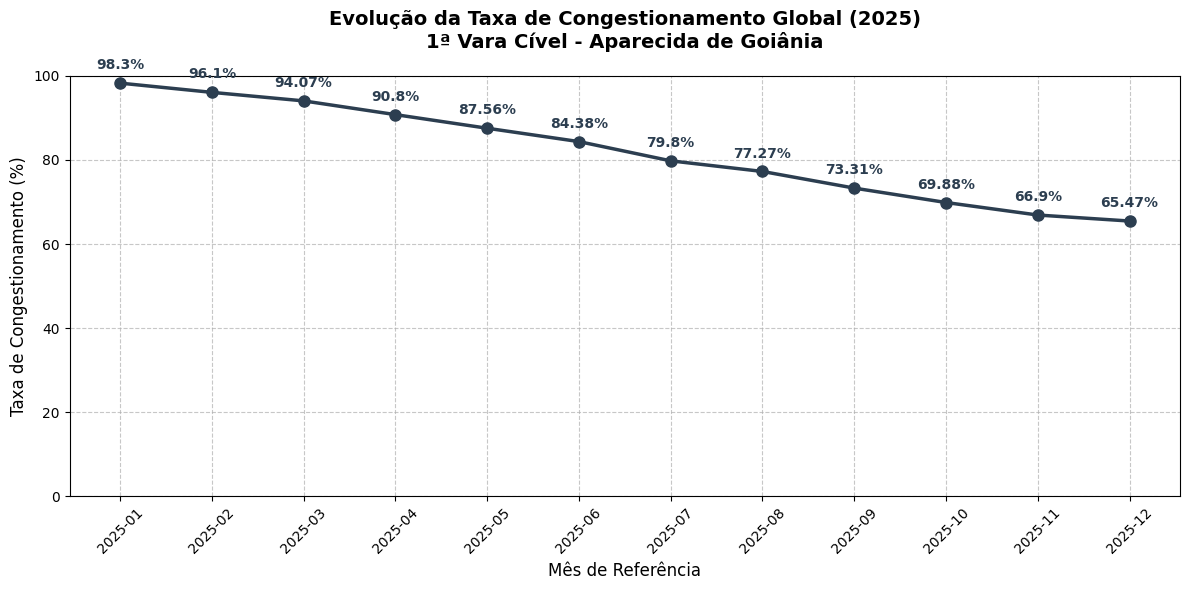

In [60]:
import matplotlib.pyplot as plt

# 1) Aplicar o seu filtro
filtro = (
    (df_global_mensal['comarca'] == 'APARECIDA DE GOIÂNIA') & 
    (df_global_mensal['serventia'] == '1ª Vara Cível') &
    (df_global_mensal['mes_ref'].astype(str).str.contains('2025'))
)

df_plot = df_global_mensal[filtro].copy()

# 2) Preparação dos dados
# Converter mes_ref para string para evitar problemas de formatação de datas no eixo X
x = df_plot['mes_ref'].astype(str).tolist()
y = df_plot['Taxa_Cong_Global (%)'].tolist()

# 3) Criação do Gráfico (Pure Matplotlib)
fig, ax = plt.subplots(figsize=(12, 6))

# Plotagem da linha e dos pontos
ax.plot(x, y, marker='o', linestyle='-', linewidth=2.5, color='#2c3e50', markersize=8, label='Taxa Global')

# 4) Estilização Técnica
ax.set_title('Evolução da Taxa de Congestionamento Global (2025)\n1ª Vara Cível - Aparecida de Goiânia', 
             fontsize=14, pad=20, fontweight='bold')
ax.set_xlabel('Mês de Referência', fontsize=12)
ax.set_ylabel('Taxa de Congestionamento (%)', fontsize=12)

# Grid personalizada (estilo whitegrid manual)
ax.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True) # Garante que o grid fique atrás da linha

# Limites do eixo Y (Taxa de 0 a 100)
ax.set_ylim(0, 100)

# 5) Adição de Data Labels (Valores sobre os pontos)
for i, valor in enumerate(y):
    ax.annotate(f'{valor}%', 
                (x[i], y[i]), 
                textcoords="offset points", 
                xytext=(0, 10), 
                ha='center', 
                fontsize=10, 
                fontweight='bold',
                color='#2c3e50')

# Rotação dos meses para melhor leitura
plt.xticks(rotation=45)

# Ajuste fino para não cortar os rótulos
plt.tight_layout()

# Exibir
plt.show()

## GRAVA ARQUIVO ANUAL NA PASTA RESULTS

In [61]:
# Grava cada arquivo MENSAL agrupado por SERVENTIA na pasta results
ano_alvo = 2025
df_mes = df_global_mensal[df_global_mensal['mes_ref'].dt.year == ano_alvo]
os.makedirs("results", exist_ok=True)
df_mes.to_csv(f"results/tx_serv_{ano_alvo}.csv", sep=",", index=False, encoding="utf-8-sig")

# Carregamento de TODOS os Arquivos CSV Limpos

In [ ]:
# Concatena os arquivos LIMPOS da pasta dataclean
# Listar os arquivos CSV na pasta 'dataclean'
arquivo_csv = glob.glob('results/clean_process_*.csv')
# Carregar os arquivos CSV e concatenar em um único DataFrame
dfs = []
for arquivo in arquivo_csv:  # lista/iterável com os caminhos tipo 'clean_process_1.csv', 'clean_process_2.csv', ...
    df_mensal = pd.read_csv(arquivo, sep='#', encoding='utf-8-sig')
    dfs.append(df_mensal)

df = pd.concat(dfs, ignore_index=True)

#print(df_results_mensal.shape)

C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_7440\3985051159.py:7: DtypeWarning: Columns (5,19,20,24,25,41,43,54,56,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mensal = pd.read_csv(arquivo, sep='#', encoding='utf-8-sig')
C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_7440\3985051159.py:7: DtypeWarning: Columns (5,19,20,22,23,25,41,43,49,54,56,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mensal = pd.read_csv(arquivo, sep='#', encoding='utf-8-sig')
C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_7440\3985051159.py:7: DtypeWarning: Columns (5,19,20,24,25,41,43,49,54,56,60,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mensal = pd.read_csv(arquivo, sep='#', encoding='utf-8-sig')
C:\Users\jcpsrodrigues\AppData\Local\Temp\ipykernel_7440\3985051159.py:7: DtypeWarning: Columns (5,20,41,43,54,60,61) have mixed types. Specify dtype option on import or set low_mem

In [44]:
print(df.shape)

(11649349, 66)


In [ ]:
df_results_mensal.head()

## GRAVA ARQUIVO MENSAL CONCATENADO, NO FORMATO JSON, NA PASTA RESULTS_CONCAT

In [ ]:
# Grava o arquivo MENSAL concatenado, no formato JSON, na pasta results_concat
os.makedirs("results_concat", exist_ok=True)
df_global_mensal.to_json("results_concat/tx_cong_mensal.json", orient="records", force_ascii=False)